In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df_raw = pd.read_csv("continuous_factory_process.csv")

In [ ]:
df_raw.head()

,time_stamp,AmbientConditions.AmbientHumidity.U.Actual,AmbientConditions.AmbientTemperature.U.Actual,Machine1.RawMaterial.Property1,Machine1.RawMaterial.Property2,Machine1.RawMaterial.Property3,Machine1.RawMaterial.Property4,Machine1.RawMaterialFeederParameter.U.Actual,Machine1.Zone1Temperature.C.Actual,Machine1.Zone2Temperature.C.Actual,...,Stage2.Output.Measurement10.U.Actual,Stage2.Output.Measurement10.U.Setpoint,Stage2.Output.Measurement11.U.Actual,Stage2.Output.Measurement11.U.Setpoint,Stage2.Output.Measurement12.U.Actual,Stage2.Output.Measurement12.U.Setpoint,Stage2.Output.Measurement13.U.Actual,Stage2.Output.Measurement13.U.Setpoint,Stage2.Output.Measurement14.U.Actual,Stage2.Output.Measurement14.U.Setpoint
0,2019-03-06 10:52:33,17.24,23.53,11.54,200,963.0,247,1241.26,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
1,2019-03-06 10:52:34,17.24,23.53,11.54,200,963.0,247,1246.09,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
2,2019-03-06 10:52:35,17.24,23.53,11.54,200,963.0,247,1246.29,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
3,2019-03-06 10:52:36,17.24,23.53,11.54,200,963.0,247,1247.59,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
4,2019-03-06 10:52:37,17.24,23.53,11.54,200,963.0,247,1252.83,72.1,72.4,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71


In [ ]:
df_raw = df_raw.copy()
df_raw.rename(columns={
    df_raw.columns[5]: "Speed",
    df_raw.columns[8]: "Temp",
    df_raw.columns[10]: "Amps",
    "Stage1.Output.Measurement1.U.Actual": "Target"
}, inplace=True)

print("Renamed Columns Confirmed:")
print(df_raw[["Speed", "Temp", "Amps", "Target"]].head())

Renamed Columns Confirmed:
   Speed  Temp   Amps  Target
0  963.0  72.0  48.03     0.0
1  963.0  72.0  48.03     0.0
2  963.0  72.0  48.16     0.0
3  963.0  72.0  48.57     0.0
4  963.0  72.1  48.57     0.0


In [ ]:
df_raw.head()

,time_stamp,AmbientConditions.AmbientHumidity.U.Actual,AmbientConditions.AmbientTemperature.U.Actual,Machine1.RawMaterial.Property1,Machine1.RawMaterial.Property2,Speed,Machine1.RawMaterial.Property4,Machine1.RawMaterialFeederParameter.U.Actual,Temp,Machine1.Zone2Temperature.C.Actual,...,Stage2.Output.Measurement10.U.Actual,Stage2.Output.Measurement10.U.Setpoint,Stage2.Output.Measurement11.U.Actual,Stage2.Output.Measurement11.U.Setpoint,Stage2.Output.Measurement12.U.Actual,Stage2.Output.Measurement12.U.Setpoint,Stage2.Output.Measurement13.U.Actual,Stage2.Output.Measurement13.U.Setpoint,Stage2.Output.Measurement14.U.Actual,Stage2.Output.Measurement14.U.Setpoint
0,2019-03-06 10:52:33,17.24,23.53,11.54,200,963.0,247,1241.26,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
1,2019-03-06 10:52:34,17.24,23.53,11.54,200,963.0,247,1246.09,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
2,2019-03-06 10:52:35,17.24,23.53,11.54,200,963.0,247,1246.29,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
3,2019-03-06 10:52:36,17.24,23.53,11.54,200,963.0,247,1247.59,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
4,2019-03-06 10:52:37,17.24,23.53,11.54,200,963.0,247,1252.83,72.1,72.4,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71


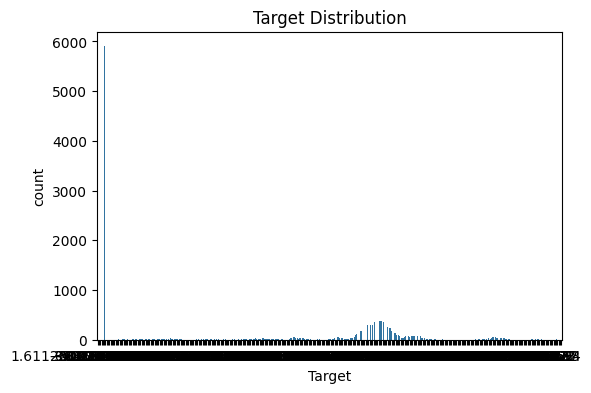

Target Class Distribution:
Target
 0.000000e+00    5900
 1.387000e+01     386
 1.386000e+01     369
 1.385000e+01     356
 1.388000e+01     355
                 ... 
 1.499000e+01       1
-3.132803e+00       1
 1.257580e-11       1
-3.435604e-03       1
 8.166780e-44       1
Name: count, Length: 359, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=df_raw)
plt.title("Target Distribution")
plt.show()

print("Target Class Distribution:")
print(df_raw["Target"].value_counts())

In [ ]:
df = df_raw.copy()

# Explicitly define the timestamp column to drop it safely
time_cols = ["time_stamp"]
df.drop(columns=time_cols, inplace=True, errors="ignore")

df.dropna(subset=["Target"], inplace=True)

# Create your custom feature
df["Thermal_Load"] = df["Temp"] * df["Amps"]

print("Cleaned Dataset Shape:", df.shape)
df.head()

Cleaned Dataset Shape: (14088, 116)


,AmbientConditions.AmbientHumidity.U.Actual,AmbientConditions.AmbientTemperature.U.Actual,Machine1.RawMaterial.Property1,Machine1.RawMaterial.Property2,Speed,Machine1.RawMaterial.Property4,Machine1.RawMaterialFeederParameter.U.Actual,Temp,Machine1.Zone2Temperature.C.Actual,Amps,...,Stage2.Output.Measurement10.U.Setpoint,Stage2.Output.Measurement11.U.Actual,Stage2.Output.Measurement11.U.Setpoint,Stage2.Output.Measurement12.U.Actual,Stage2.Output.Measurement12.U.Setpoint,Stage2.Output.Measurement13.U.Actual,Stage2.Output.Measurement13.U.Setpoint,Stage2.Output.Measurement14.U.Actual,Stage2.Output.Measurement14.U.Setpoint,Thermal_Load
0,17.24,23.53,11.54,200,963.0,247,1241.26,72.0,72.3,48.03,...,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71,3458.160
1,17.24,23.53,11.54,200,963.0,247,1246.09,72.0,72.3,48.03,...,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71,3458.160
2,17.24,23.53,11.54,200,963.0,247,1246.29,72.0,72.3,48.16,...,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71,3467.520
3,17.24,23.53,11.54,200,963.0,247,1247.59,72.0,72.3,48.57,...,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71,3497.040
4,17.24,23.53,11.54,200,963.0,247,1252.83,72.1,72.4,48.57,...,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71,3501.897


In [ ]:

threshold = df["Target"].quantile(0.80)
df["Target"] = (df["Target"] >= threshold).astype(int)

X = df.drop(columns=["Target"])
y = df["Target"]


X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Target values now:")
print(y.value_counts())

Target values now:
Target
0    11199
1     2889
Name: count, dtype: int64


In [ ]:
print(df["Target"].describe())

count    14088.000000
mean         0.205068
std          0.403766
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Target, dtype: float64


In [ ]:
threshold = df["Target"].quantile(0.80)

df["Target"] = (df["Target"] >= threshold).astype(int)

df["Target"].value_counts()

,count
Target,
0,11199
1,2889


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
# Train models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Predictions
dt_preds = dt_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Accuracy scores
dt_acc = accuracy_score(y_test, dt_preds)
rf_acc = accuracy_score(y_test, rf_preds)

print(dt_acc)
print(rf_acc)

0.9460610361958836
0.9591909155429382


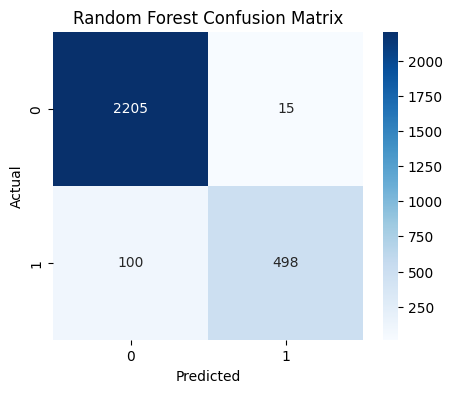

In [ ]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top Root Causes:")
print(feature_importance.head(10))

Top Root Causes:
                                              Feature  Importance
68               Stage1.Output.Measurement14.U.Actual    0.086666
44                Stage1.Output.Measurement2.U.Actual    0.059786
39  FirstStage.CombinerOperation.Temperature2.U.Ac...    0.057909
35                 Machine3.MaterialPressure.U.Actual    0.051052
38  FirstStage.CombinerOperation.Temperature1.U.Ac...    0.047249
48                Stage1.Output.Measurement4.U.Actual    0.047174
41                Stage1.Output.Measurement0.U.Actual    0.036869
58                Stage1.Output.Measurement9.U.Actual    0.028339
80                     Machine5.Temperature4.C.Actual    0.027142
56                Stage1.Output.Measurement8.U.Actual    0.026098


In [ ]:
feature_importance.to_csv("feature_importance.csv", index=False)

In [ ]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_acc, rf_acc]
})

print("\nModel Comparison:")
print(results)

results.to_csv("model_accuracy.csv", index=False)


Model Comparison:
           Model  Accuracy
0  Decision Tree  0.946061
1  Random Forest  0.959191
